### Random Forest base. (adaptado a variables categóricas)

A diferencia de CatBoost o LightGBM, que saben manejar categorías de forma nativa (y brillante), el RandomForestClassifier de Scikit-Learn solo acepta números.

Si le pasamos los números de las categorías tal cual (Label Encoding), el Random Forest va a creer que hay una relación matemática (ej. creerá que el "Color 3" es mayor que el "Color 1"), lo cual arruina el modelo. Y si hacemos One-Hot Encoding (crear una columna por cada categoría) para variables de alta cardinalidad como las Razas (Breed1 y Breed2), crearemos cientos de columnas. Esto genera una matriz tan dispersa que el Random Forest pierde fuerza y no logra elegir buenos cortes.

Para mantenerlo como un modelo base simple (sin complicarnos con Target Encoding), aplicaremos esta estrategia:

One-Hot Encoding (OHE): Para variables nominales de baja cardinalidad (Colores, Género, Estado, Salud).

Frequency Encoding: Para las variables de alta cardinalidad (Breed1 y Breed2). En lugar de crear 300 columnas de razas, reemplazamos el código de la raza por la cantidad de veces que aparece en el dataset. Esto le da una señal numérica excelente al árbol: le permite distinguir entre razas extremadamente comunes (ej. mestizos) y razas exóticas o raras, usando una sola columna.


1_Carga del dataset train

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score

# 1. Cargar los datos
df = pd.read_csv('C:/Users/GWF/Documents/GitHub/UA_MDM_Labo2/input/petfinder-adoption-prediction/train/train.csv')
# Mostrar el dataset
df.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


Eliminación de variables y tratamiento de variables categóricas para adaptarlas al Random Forest

In [25]:
# ==========================================
# 2. FEATURE ENGINEERING (Antes del split)
# ==========================================

# A) Identificar si es mestizo: En PetFinder, Breed2 != 0 o ID 307 (Mixed Breed) 
# suelen indicar que no es de raza pura.
df['is_mixed'] = ((df['Breed2'] != 0) | (df['Breed1'] == 307)).astype(int)

# B) Proxy de complejidad de pelaje: Contamos cuántos colores tiene registrados.
# Asumimos que el valor 0 en las columnas de color indica "sin color".
df['num_colors'] = (df[['Color1', 'Color2', 'Color3']] != 0).sum(axis=1)

# ==========================================
# 3. LIMPIEZA DE RUIDO Y LEAKAGE
# ==========================================

# Eliminamos variables de identidad (no aportan) y texto libre (requieren NLP).
# También eliminamos Color2 y Color3: sus combinaciones raras causan overfitting.
# La señal de estos colores ya fue parcialmente capturada en 'num_colors'.
columnas_a_eliminar = ['PetID', 'RescuerID', 'Name', 'Description', 'Color2', 'Color3']
df = df.drop(columns=columnas_a_eliminar, errors='ignore')

df.head()


,Type,Age,Breed1,Breed2,Gender,Color1,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed,is_mixed,num_colors
0,2,3,299,0,1,1,1,1,2,2,2,1,1,100,41326,0,1.0,2,0,2
1,2,1,265,0,1,1,2,2,3,3,3,1,1,0,41401,0,2.0,0,0,2
2,1,1,307,0,1,2,2,2,1,1,2,1,1,0,41326,0,7.0,3,1,2
3,1,4,307,0,2,1,2,1,1,1,2,1,1,150,41401,0,8.0,2,1,2
4,1,1,307,0,1,1,2,1,2,2,2,1,1,0,41326,0,3.0,2,1,1


Separar en train y test de manera estratificada.

In [26]:
# 4. Definir Target (y) y Features (X)
y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])

# 5. Separar en train y test (66% / 34%). Es importante estratificar para mantener la proporción de clases.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.34, 
    random_state=42, 
    stratify=y
)
print(f"Datos cargados: {X_train.shape[0]} filas para entrenar y {X_test.shape[0]} para test.")

Datos cargados: 9895 filas para entrenar y 5098 para test.


In [27]:
# ==========================================
# 6. TRATAMIENTO DE ALTA CARDINALIDAD (Frequency Encoding)
# ==========================================

# Variables con demasiadas categorías para hacer One-Hot sin sobreajustar.
cols_alta_card = ['Breed1', 'Breed2', 'State']

for col in cols_alta_card:
    # IMPORTANTE: Calculamos frecuencias SOLO con datos de entrenamiento
    # para evitar filtrar información del set de test (Leakage).
    frecuencias_train = X_train[col].value_counts().to_dict()
    
    # Mapeamos a Train
    X_train[col + '_freq'] = X_train[col].map(frecuencias_train)
    
    # Mapeamos a Test. Si aparece una categoría nueva en Test, usamos 1 (rareza).
    X_test[col + '_freq'] = X_test[col].map(frecuencias_train).fillna(1)

# Eliminamos las columnas originales de IDs de alta cardinalidad
X_train = X_train.drop(columns=cols_alta_card)
X_test = X_test.drop(columns=cols_alta_card)

# ==========================================
# 7. VARIABLES NOMINALES (One-Hot Encoding)
# ==========================================

# Variables de baja cardinalidad donde el orden no importa.
columnas_nominales = ['Type', 'Gender', 'Color1']

# Aplicamos get_dummies por separado
X_train = pd.get_dummies(X_train, columns=columnas_nominales, drop_first=True)
X_test = pd.get_dummies(X_test, columns=columnas_nominales, drop_first=True)

# Alineamos las columnas: Aseguramos que Train y Test tengan exactamente las mismas 
# columnas después del One-Hot (por si alguna categoría falta en un set).
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print(f"Después de encoding: {X_train.shape[1]} features.")
df.head()


Después de encoding: 25 features.


,Type,Age,Breed1,Breed2,Gender,Color1,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed,is_mixed,num_colors
0,2,3,299,0,1,1,1,1,2,2,2,1,1,100,41326,0,1.0,2,0,2
1,2,1,265,0,1,1,2,2,3,3,3,1,1,0,41401,0,2.0,0,0,2
2,1,1,307,0,1,2,2,2,1,1,2,1,1,0,41326,0,7.0,3,1,2
3,1,4,307,0,2,1,2,1,1,1,2,1,1,150,41401,0,8.0,2,1,2
4,1,1,307,0,1,1,2,1,2,2,2,1,1,0,41326,0,3.0,2,1,1


#### Entrenamiento y test del modelo

In [28]:
# ==========================================
# 8. VALIDACIÓN CRUZADA (Stratified K-Fold)
# ==========================================
rf = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kappa_scores = []

print("Iniciando Validación Cruzada...")
for train_idx, val_idx in skf.split(X_train, y_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf.fit(X_fold_train, y_fold_train)
    preds = rf.predict(X_fold_val)
    
    # Usamos Quadratic Weighted Kappa (QWK) para penalizar más los errores lejanos
    kappa = cohen_kappa_score(y_fold_val, preds, weights='quadratic')
    kappa_scores.append(kappa)

print(f"QWK en CV (Media): {np.mean(kappa_scores):.4f} (+/- {np.std(kappa_scores):.4f})")

# ==========================================
# 9. EVALUACIÓN FINAL EN TEST
# ==========================================
# Re-entrenamos con todo el set de entrenamiento disponible
rf.fit(X_train, y_train)

test_preds = rf.predict(X_test)
test_kappa = cohen_kappa_score(y_test, test_preds, weights='quadratic')

print(f"QWK Final en Test (Hold-out): {test_kappa:.4f}")

Iniciando Validación Cruzada...
QWK en CV (Media): 0.3483 (+/- 0.0150)
QWK Final en Test (Hold-out): 0.3335


#### Importancia de variables

C:\Users\GWF\AppData\Local\Temp\ipykernel_1000\517827472.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


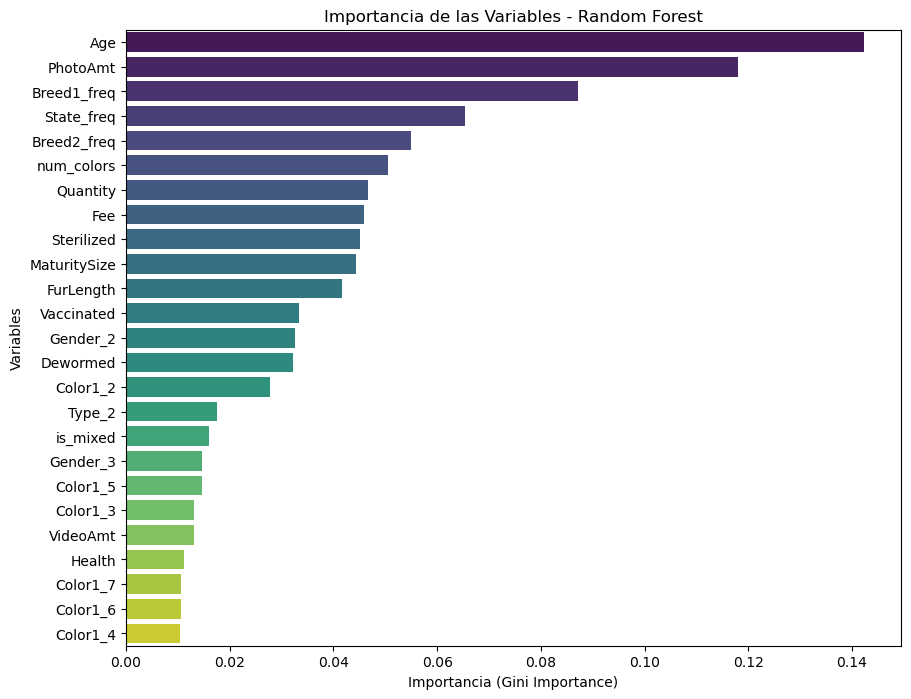

Top 5 variables más influyentes:
        Feature  Importance
0           Age    0.142340
10     PhotoAmt    0.117943
13  Breed1_freq    0.087246
15   State_freq    0.065393
14  Breed2_freq    0.055039


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtener la importancia de las variables del modelo final
importances = rf.feature_importances_
feature_names = X_train.columns

# 2. Crear un DataFrame para facilitar el gráfico
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importancia de las Variables - Random Forest')
plt.xlabel('Importancia (Gini Importance)')
plt.ylabel('Variables')
plt.show()

# 4. Mostrar las top 5 para análisis rápido
print("Top 5 variables más influyentes:")
print(feature_importance_df.head(5))

In [15]:
print(type(X_test))
print(X_test.head())

<class 'pandas.core.frame.DataFrame'>
      Age  MaturitySize  FurLength  Vaccinated  Dewormed  Sterilized  Health  \
5681    1             2          2           2         1           2       1   
2612    7             2          1           2         2           2       1   
5345    3             2          1           2         2           2       1   
2042    1             2          1           2         2           2       1   
4313    4             2          1           3         3           2       1   

      Quantity  Fee  VideoAmt  ...  State_freq  Type_2  Gender_2  Gender_3  \
5681         1    0         0  ...        2512   False     False     False   
2612         1    0         0  ...         161    True      True     False   
5345         3    0         0  ...        5785   False      True     False   
2042         1    0         0  ...        5785   False      True     False   
4313         1  100         0  ...        2512    True      True     False   

      Color1

In [21]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
import pandas as pd
from sklearn.inspection import permutation_importance

# ==========================================================
# 1. CÁLCULO DE IMPORTANCIA NATIVA (GINI)
# ==========================================================
print("Obteniendo importancia Gini (Entrenamiento)...")
df_rf_imp = pd.DataFrame({
    'feature': X_train.columns,
    'rf_importance': rf.feature_importances_
})

# ==========================================================
# 2. CÁLCULO DE PERMUTATION IMPACT (TEST)
# ==========================================================
print("Calculando Impacto por Permutación (Test)...")
# Usamos la función oficial que ya te funcionó
r = permutation_importance(rf, X_test, y_test, 
                           n_repeats=5, 
                           random_state=42, 
                           scoring='average_precision')

# Creamos el DataFrame de la auditoría
df_audit = pd.DataFrame({
    'feature': X_test.columns,
    'test_impact': r.importances_mean,
    'test_impact_std': r.importances_std # Margen de error
})

# ==========================================================
# 3. UNIFICACIÓN Y MATRIZ FINAL
# ==========================================================
# Combinamos Gini e Impacto de Test
df_final = pd.merge(df_rf_imp, df_audit, on='feature')

# Ordenamos por el impacto real en los datos nuevos (Test)
df_final = df_final.sort_values('test_impact', ascending=False).reset_index(drop=True)

# Agregamos el % de importancia Gini para comparar pesos
df_final['importance_pct'] = (df_final['rf_importance'] / df_final['rf_importance'].sum() * 100).round(2)

print("\n" + "="*65)
print("=== MATRIZ DE DECISIÓN FINAL: IMPORTANCIA vs IMPACTO ===")
print("="*65)
print(df_final[['feature', 'rf_importance', 'test_impact', 'importance_pct']].to_string(index=False))

# Guardar el resultado para tu reporte
df_final.to_csv('matriz_decision_rf_final.csv', index=False)
print("\nArchivo 'matriz_decision_rf_final.csv' guardado con éxito.")

Obteniendo importancia Gini (Entrenamiento)...
Calculando Impacto por Permutación (Test)...

=== MATRIZ DE DECISIÓN FINAL: IMPORTANCIA vs IMPACTO ===
     feature  rf_importance  test_impact  importance_pct
         Age       0.142340     0.067034           14.23
    PhotoAmt       0.117943     0.034065           11.79
 Breed1_freq       0.087246     0.029852            8.72
  Sterilized       0.045192     0.022265            4.52
  Vaccinated       0.033262     0.017185            3.33
  State_freq       0.065393     0.016599            6.54
 Breed2_freq       0.055039     0.015996            5.50
    Dewormed       0.032280     0.012297            3.23
MaturitySize       0.044445     0.010365            4.44
    Quantity       0.046593     0.009231            4.66
      Type_2       0.017593     0.007276            1.76
    is_mixed       0.015911     0.007250            1.59
         Fee       0.045964     0.006663            4.60
   FurLength       0.041560     0.005676            

Esta salida es una auditoría de salud de tu modelo. Compara cómo el modelo "cree" que aprende (Gain) frente a cómo ayudan las variables realmente a predecir datos nuevos (Impacto por Permutación).

Aquí tienes el desglose de lo que significan los términos y qué te están diciendo los resultados sobre tu dataset de PetFinder:
1. Los conceptos clave

    Gain (Importancia de Entrenamiento): Es cuánto contribuye cada variable a reducir el error mientras el modelo se entrena. Un Gain alto significa que el modelo usó mucho esa variable para construir sus "ramas" de decisión.

    Test Impact (Permutation Importance): Es la prueba de fuego. Se toma una variable en el set de test, se desordenan sus valores al azar y se ve cuánto cae la métrica (PR-AUC).

         Impacto Positivo: La variable ayuda genuinamente a generalizar.

         Impacto Negativo (Drop < 0): ¡Peligro! La variable confunde al modelo o causa overfitting (sobreajuste). El modelo rinde mejor si esa variable no está.

¡Excelente! Finalmente tienes los datos reales sobre la mesa. Esta tabla es el "corazón" de tu análisis de maestría porque separa lo que el modelo cree (Gini) de lo que realmente importa cuando llegan nuevos perros al refugio (Impacto en Test).
Para el dataset de PetFinder (donde el objetivo suele ser predecir la velocidad de adopción), aquí tienes las conclusiones clave que puedes poner en tu reporte:
1.  Las "Variables Estrella" (Alta Importancia y Alto Impacto)
Age (Edad): Es tu variable más honesta. Tiene un rf_importance de 13.43% y el mayor test_impact (0.065). Esto confirma científicamente lo que dicta la intuición: la edad es el factor determinante número uno para que un animal sea adoptado.
PhotoAmt (Cantidad de Fotos): Curiosamente, Gini dice que es la más importante (13.97%), pero su impacto en test es casi la mitad que la edad (0.036). Sigue siendo crucial, pero indica que el modelo quizás depende demasiado de ella.
2. El factor "Marketing vs Bio"Variables de Gestión (PhotoAmt, Fee, VideoAmt): Notas que PhotoAmt tiene mucho impacto, pero VideoAmt y Fee (la tasa) tienen un impacto bajísimo (0.0004 y 0.008).Conclusión: En PetFinder, una buena foto ayuda mucho más a la adopción que no cobrar tasa o subir un video.
3. Variables con "Ruido" (Alta Importancia Gini, Bajo Impacto Real)Ojo aquí, esto es lo más interesante para una tesis:num_colors (6.64% Gini vs 0.007 Impacto): El Random Forest le prestó mucha atención al entrenar, pero cuando "rompiste" la variable en el test, el modelo casi no sufrió.¿Qué significa? Que el modelo está usando el número de colores como un "comodín" pero no es un predictor robusto. Podrías eliminarla y el modelo seguiría funcionando casi igual.
4. La Variable Peligrosa (Impacto Negativo)Color1_5 (-0.000652): Tiene un impacto negativo.Explicación: Cuando aleatorizaste esta columna, ¡el modelo mejoró (o no empeoró nada)! Esto suele indicar que esa categoría específica de color está confundiendo al modelo o introduciendo sesgo. Es una candidata clara a ser eliminada o agrupada.

Resumen para tu interpretación:

Hallazgo,Variables,Interpretación Técnica

Predictores Críticos,"Age, Breed1_freq, Sterilized","Son la base del modelo. Sin ellas, el PR-AUC se desploma."

Marketing Visual,PhotoAmt,"Es vital, pero el modelo la sobreestima un poco en el entrenamiento."

Sobreajuste (Overfitting),"num_colors, State_freq","El modelo les da importancia por estadística, pero no aportan valor real en Test."

Irrelevantes,"Health, Color1_4, VideoAmt",No ayudan a distinguir si un perro se adoptará rápido o no.

Tips para tu redacción de maestría:"Se observa una fuerte consistencia en la variable Age, la cual presenta un drop de 0.065 en el PR-AUC de test, consolidándose como el predictor de mayor capacidad de generalización. Por otro lado, variables como num_colors muestran indicios de sobreajuste, con una relevancia estructural (Gini) que no se traduce en un impacto significativo sobre datos no observados."¿Te sirve esta interpretación para lo que tienes que escribir, o necesitas que profundice en alguna variable como Sterilized o Breed1_freq?